# Data Distribution Analysis Guide


## Overview
In this notebook, we will explore how to analyze data distributions by following a structured approach. 

The guide will cover understanding the data type, identifying the analytical question, calculating descriptive statistics, interpreting graphs and statistics.

The notebook has a toggle markdown cell `"Compare Answer"`
You can click to toggle to validate if your answer is close. It does not have to be exact. 

Recommended to use the markdown files in the repo as they have summarised steps overview with the relevant calculations.




## Learning Objectives

At the end of this notebook, you should be able to:

- Classify a variable as discrete or continuous.
- Select a candidate distribution (normal, exponential, binomial, Poisson, uniform) for a given variable.
- Compute descriptive statistics and plot a histogram to describe a distribution.
- Compare a histogram against a fitted distribution's PDF to judge how well it fits.


## The four-step approach

Each case study below works through these steps:

1. Understand the Data Type: Continuous or discrete.

2. Identify the Analytical Question: Determine which distribution fits your question.

3. Calculate Descriptive Statistics: Compute and visualize summary statistics.

4. Interpret the Graph and Descriptive Statistics: Analyze the data’s distribution and patterns.



---



## Case Study: Time Between Customer Purchases
You will be guided step-by-step:



Scenario: An e-commerce company wants to analyze the time between customer purchases to optimize marketing strategies. 

They suspect the time between purchases follows an Exponential distribution.


---

## 1. Understand the Data Type

### Step: Determine Whether Your Data is Continuous or Discrete

- **Discrete Data**: Takes on distinct, separate values. Examples include the number of emails received in an hour or the number of customer complaints. Common distributions for discrete data include:
  - **Binomial Distribution**: Used when counting the number of successes in a fixed number of trials.
  - **Poisson Distribution**: Used for modeling the number of events in a fixed interval of time or space.

- **Continuous Data**: Takes on any value within a range. Examples include height, temperature, or time. Common distributions for continuous data include:
  - **Normal Distribution**: Used for data that is symmetrically distributed around the mean.
  - **Exponential Distribution**: Used for modeling the time between events.
  - **Log-Normal Distribution**: Used for data that is normally distributed when logged.

- **Why It Matters**: The type of data determines which probability distribution and statistical methods are appropriate for analysis.



### Choosing a distribution: a quick map

The data type is the first fork on the way to a distribution. Use this as a rough guide (it shows the families you meet most often, not every possibility):

```mermaid
flowchart TD
    A[Your data] --> B{Discrete or continuous?}
    B -->|Discrete counts| C{What are you counting?}
    B -->|Continuous measure| D{What shape?}
    C -->|Successes in n trials| E[Binomial]
    C -->|Events per interval| F[Poisson]
    D -->|Symmetric, bell-shaped| G[Normal]
    D -->|Time between events| H[Exponential]
    D -->|Equally likely in a range| I[Uniform]
```

For the fuller picture, see the univariate distribution relationships chart (Leemis and McQueston) and the `scipy.stats` distribution list linked at the end.


### Question: What type of data are we working with in the case study?



#### Your answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The data is continuous because it represents the time between customer purchases, which can take any positive value.</p>
  
</details>

---


## 2. Identify the Analytical Question

### Step: Define the Problem or Question You Need to Address

- **Questions to Consider**:
  - Are you predicting an outcome?
  - Are you testing for differences?
  - Are you estimating probabilities?

- **Distribution Choice**:
  - **Binomial Distribution**: Appropriate for counting successes in a fixed number of trials (e.g., the number of heads in coin flips).
  - **Exponential Distribution**: Suitable for modeling time between events (e.g., the time between bus arrivals).
  - **Normal Distribution**: Often used for continuous data that follows a bell-shaped curve.

- **Why It Matters**: Different questions and data types require different distributions and statistical methods to accurately address the problem.



### Question: What is the main question or goal for this analysis?

#### Your Answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The goal is to determine whether the time between customer purchases follows an Exponential distribution and to visualize this distribution.</p>
  
</details>

---

## 3. Calculate Descriptive Statistics

### Step: Compute Summary Statistics to Describe the Data

- **Descriptive Statistics**:
  - **For Discrete Data**: Mean, median, mode, variance, and standard deviation.
  - **For Continuous Data**: Mean, median, variance, standard deviation, skewness, and kurtosis.

- **Visualizations**:
  - **Histograms**: To visualize the distribution of data.
  - **Bar Charts**: For discrete data counts.
  - **Box Plots**: To assess the spread and central tendency.

- **Why It Matters**: Descriptive statistics provide a summary of the data’s main features, which helps in understanding its distribution and characteristics.



### Question: What descriptive statistics should we calculate for this data?


#### Your Answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>Calculate the mean and standard deviation of the time between purchases. For an Exponential distribution,
  
   the mean should be equal to  1/𝜆

​and the standard deviation should also be 1/𝜆

​, where 
𝜆 is the rate parameter.</p>
  
</details>

---

## 4. Interpret the Graph and Descriptive Statistics

### Step: Analyze the Graphical Representation and Descriptive Statistics

- **Graphs**:
  - Examine the shape, center, and spread of the data.
  - Identify patterns, outliers, and whether the data fits the expected distribution shape.

- **Descriptive Statistics**:
  - Assess the mean, median, variance, and other statistics to understand the data’s distribution and central tendencies.

- **Why It Matters**: Interpretation helps in understanding how well the data fits the assumed distribution and in identifying any anomalies or patterns.

[Scipy stats docs](https://docs.scipy.org/doc/scipy/reference/stats.html)

### Question: How can we interpret the histogram and the descriptive statistics?

In [1]:
# We will import the necessary package

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import (
    expon,
)  # our stats package that contains the functions, here we import expon specifically

In [2]:
# You need not worry about the generation of the data specifically.

# Generating synthetic data for time between purchases

np.random.seed(3)  # this allows us to make the results reproducable

data = np.random.exponential(scale=10, size=365)  # Mean time of 10 units

In [3]:
# Next we must calculate the descriptive stats. We will utilize np again for this, its just convenient. If the data was stored in a DF you can use
# pandas methods

# Descriptive statistics
mean_time = np.mean(data)
std_dev_time = np.std(data)

In [4]:
# check the output
print(f" the mean number of time are {mean_time}")
print(f" the standard deviation of time are {std_dev_time}")

 the mean number of time are 9.561474322984747
 the standard deviation of time are 9.464251581018065


Text(0, 0.5, 'Frequency')

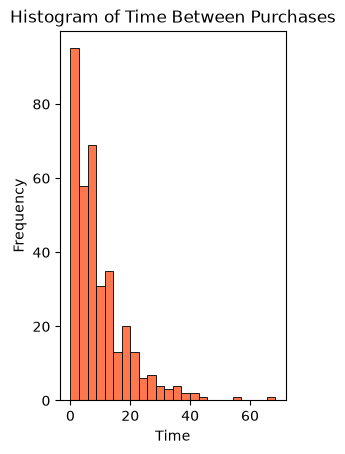

In [5]:
""" Histogram of Time Between Purchases:

Interpretation:
The histogram represents the frequency distribution of the time intervals between customer purchases.
For an exponential distribution, the histogram typically shows a rapid decline,
 with most of the data concentrated near the lower values. 
 This pattern indicates that shorter intervals between purchases are more common, and longer intervals are less frequent.
The shape of the histogram, with a high frequency of small time intervals and a long tail towards the right, 
aligns with the characteristics of an exponential distribution.

"""
plt.subplot(1, 2, 1)
sns.histplot(data, kde=False, color="#ff4a11ff")
plt.title("Histogram of Time Between Purchases")
plt.xlabel("Time")
plt.ylabel("Frequency")

Text(0, 0.5, 'Probability Density')

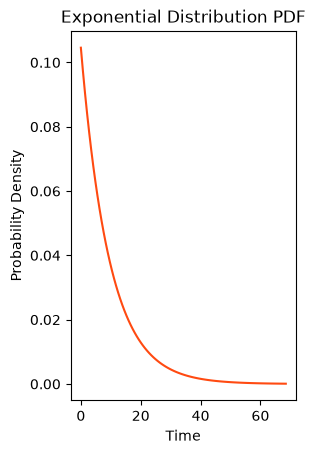

In [6]:
"""Exponential Distribution PDF (Probability Density Function) Plot:

Interpretation:
The PDF plot represents the theoretical exponential distribution curve based on the mean of the data.
The curve starts high and decays rapidly as time increases,
 indicating that the likelihood of longer intervals between purchases decreases exponentially.
The alignment between the histogram and the PDF plot suggests that the observed data follows an exponential distribution, 
with the majority of intervals being short and fewer longer intervals.
"""

# Exponential Distribution Plot
x = np.linspace(0, max(data), 100)
pdf = expon.pdf(x, scale=mean_time)
plt.subplot(1, 2, 2)
plt.plot(x, pdf, color="#ff4a11ff")
plt.title("Exponential Distribution PDF")
plt.xlabel("Time")
plt.ylabel("Probability Density")

---

## Case Study: Delivery Times


We will now look at another scenario following a different type of distribution


Scenario: A logistics company tracks the delivery times for packages and wants to analyze if these times follow a Normal distribution to improve delivery estimates.


Hint: You can refer to the detailed overview steps from previous case study and also use the markdown file(it contains a summary of the steps and metrics to be calculated for the respective distributions). I will list the overview steps in order to not make it longer.

There is a section where you have to calculate the descriptive stats. 

1. Understand the Data Type: Continuous or discrete.

2. Identify the Analytical Question: Determine which distribution fits your question.

3. Calculate Descriptive Statistics: Compute and visualize summary statistics.

4. Interpret the Graph and Descriptive Statistics: Analyze the data’s distribution and patterns.


---

## Step 1: Understand the Data Type 



### Question: What type of data are we working with?

#### Your Answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The data is continuous because it represents delivery times, which can take any positive value.</p>
  
</details>

---

## Step 2:  Identify the Analytical Question

### Question: What is the main question or goal for this analysis?

#### Your Answer here


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The goal is to determine if the delivery times follow a Normal distribution and to visualize this distribution.
</p>
  
</details>

--- 

## Step 3:  Calculate Descriptive Statistics

### Question: What descriptive statistics should we calculate for this data?
hint:  Refer to step 3 in the markdown file for distribution_functions


#### Your answer here: 


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>Calculate the mean and standard deviation of the delivery times. For a Normal distribution, these values describe the center and spread of the distribution.
</p>
  
</details>

--- 

## Step 4: Interpret the Graph and Descriptive Statistics

### Question: How can we interpret the histogram and the descriptive statistics?

#### Your Answer here

<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>The histogram should show the distribution of delivery times. If the data fits a Normal distribution, the mean and standard deviation should reflect the shape of the Normal curve.

</p>
  
</details>

In [7]:
# Generating the data, once again this is for the example you are not expected to know this.

from scipy.stats import norm  # importing norm function

# Generating synthetic data for delivery times
np.random.seed(5)
data = np.random.normal(
    loc=50, scale=10, size=365
)  # Mean of 50 units, std deviation of 10 units

In [8]:
# calculate the descriptive stats
mean_time = np.mean(data)
std_dev_time = np.std(data)

In [9]:
# check the output
print(f" the mean: {mean_time}")
print(f" the standard_deviation: {std_dev_time}")

 the mean: 50.16432690561987
 the standard_deviation: 9.7276202089247


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p> 
 the mean number of defects are 2.02
 
 the variance of defects are 1.8796000000000002
</p>
  
</details>

Text(0, 0.5, 'Frequency')

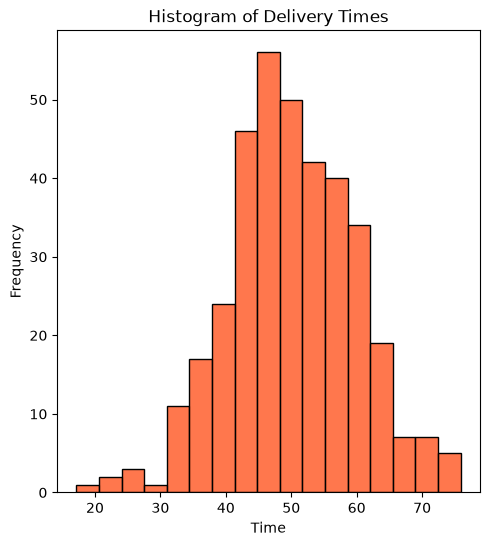

In [10]:
# Plotting
plt.figure(figsize=(12, 6))
"""
Histogram of Delivery Times:

Interpretation:
The histogram represents the frequency distribution of the delivery times.
If the data is normally distributed, the histogram should have a bell-shaped curve,
 with most data points concentrated around the mean (50 units) and tapering off symmetrically towards the tails.
The histogram shows that most delivery times are clustered around 50 units, 
with fewer occurrences as you move further away from the mean.
 This bell-shaped pattern confirms that the data follows a normal distribution.



"""

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(data, kde=False, color="#ff4a11ff")
plt.title("Histogram of Delivery Times")
plt.xlabel("Time")
plt.ylabel("Frequency")

Text(0, 0.5, 'Probability Density')

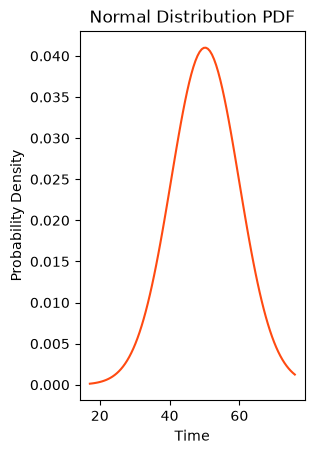

In [11]:
""" 

Normal Distribution PDF (Probability Density Function) Plot:

Interpretation:
The PDF plot represents the theoretical normal distribution curve based on the mean and standard deviation of the data.
The curve peaks at the mean (50 units) and decreases symmetrically as you move away from the mean.
The PDF plot should align well with the shape of the histogram. 
This alignment indicates that the observed delivery times follow a normal distribution.
The area under the curve represents the probability of different delivery times occurring.
"""


# Normal Distribution Plot
x = np.linspace(min(data), max(data), 100)
pdf = norm.pdf(x, mean_time, std_dev_time)
plt.subplot(1, 2, 2)
plt.plot(x, pdf, color="#ff4a11ff")
plt.title("Normal Distribution PDF")
plt.xlabel("Time")
plt.ylabel("Probability Density")

## Summary

In this notebook you:

- Classified two continuous variables and matched each to a distribution: exponential for the time between purchases, normal for delivery times.
- Computed the mean and standard deviation for each, and read them against the expected distribution.
- Plotted each histogram next to the fitted PDF to judge how well the data fit.

The companion file `consideration_for_distribution_function.md` works as a cheat sheet for the steps and the per-distribution formulas. Steps 5 to 7 (formal fit testing) are covered later, in Hypothesis testing.

## References & Further Reading

- [**scipy.stats reference**](https://docs.scipy.org/doc/scipy/reference/stats.html): The distribution objects used here, including `expon` and `norm`.
- [**NumPy random sampling**](https://numpy.org/doc/stable/reference/random/index.html): How the synthetic samples in this notebook are generated.
- [**From Data to Viz**](https://www.data-to-viz.com/): A decision tree for choosing the right chart to show a distribution, with common pitfalls.
